### Step 1 - Data Acquisition and clean-up

I'll start with the vivaldi font. It's 'cursive-like' styling may give interesting results for the NN's classification attempts.

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('character+font+images/vivaldi.csv')

#Extract pixel data
pixel_cols = [f"r{row}c{col}" for row in range(20) for col in range(20)]
    
#Normalize 0-255 data to 0-1 data
xs_flat = df[pixel_cols].to_numpy() / 255.0

#Reshape from (samples, 400) to (samples, 20, 20)
Xs = xs_flat.reshape(-1, 20, 20)

#Extract Ys
unique_chars = sorted(df['m_label'].unique())

#Make conversion dictionaries
char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

ys_mapped = df['m_label'].map(char_to_idx).to_numpy()
Ys = ys_mapped.reshape(-1, 1)

### Step 2 - Building a pytorch network

In [15]:
import torch;
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Reshape Xs to (-1, 1, 20, 20) as required by PyTorch Conv2d
Xs_reshaped = Xs.reshape(-1, 1, 20, 20)

# 2. Split into Train and Test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    Xs_reshaped, Ys, test_size=0.2, random_state=42
)

# 3. Convert NumPy arrays to PyTorch Tensors
# Note: PyTorch expects labels to be a flat 1D tensor of integers (LongTensor) for classification
train_features = torch.tensor(X_train, dtype=torch.float32)
train_labels = torch.tensor(y_train, dtype=torch.long).squeeze()

test_features = torch.tensor(X_test, dtype=torch.float32)
test_labels = torch.tensor(y_test, dtype=torch.long).squeeze()

# 4. Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(train_features, train_labels)
test_dataset = TensorDataset(test_features, test_labels)

# Batch size of 64 or 128 usually works great for this size of data
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class CharacterCNN(nn.Module):
    def __init__(self, num_classes):
        super(CharacterCNN, self).__init__()
        # Conv 1: 1 input channel (grayscale), 16 output filters, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv 2: 16 input channels, 32 output filters, 3x3 kernel
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        # Dense Layers
        # 32 channels * 5x5 image size = 800 flattened features
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, num_classes) # num_classes is len(char_to_idx)

    def forward(self, x):
        # Forward pass through layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the tensor for the dense layer: (batch_size, 800)
        x = x.view(-1, 32 * 5 * 5)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Output raw logits (CrossEntropyLoss handles softmax automatically)
        return x

# Instantiate the model
# ...moved to next code block to re-instantiate before training

##### Generalized Setup + Training Loop

In [17]:
import torch.optim as optim

def SetupAndTrain(model, num_epochs, train_loader_local):

    # 1. Choose the device (use GPU if available, otherwise CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # 2. Define Loss Function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()  # Set model to training mode
        running_loss = 0.0
        
        for inputs, labels in train_loader_local:
            # Move tensors to the configured device (CPU or GPU)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero out the gradients from the last step
            optimizer.zero_grad()
            
            # Forward pass: compute predicted outputs by passing inputs to the model
            outputs = model(inputs)
            
            # Calculate the loss
            loss = criterion(outputs, labels)
            
            # Backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            
            # Perform a single optimization step (parameter update)
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader_local.dataset)
        
        # --- EVALUATION PHASE ---
        model.eval()  # Set model to evaluation mode
        correct = 0
        total = 0

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Turn off gradients for evaluation (saves memory and speeds up math)
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                
                # The outputs are raw scores (logits). The highest score is our prediction.
                # torch.max returns (values, indices). We only care about the indices.
                _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_test_acc = (correct / total) * 100
        
        print(f"Epoch [{epoch+1}/{num_epochs}] "
            f"| Train Loss: {epoch_train_loss:.4f} "
            f"| Test Accuracy: {epoch_test_acc:.2f}%")
        

num_classes = len(char_to_idx)
cnnModel = CharacterCNN(num_classes)
SetupAndTrain(cnnModel, 100, train_loader)

Epoch [1/100] | Train Loss: 5.4769 | Test Accuracy: 0.52%
Epoch [2/100] | Train Loss: 5.4347 | Test Accuracy: 1.05%
Epoch [3/100] | Train Loss: 5.3340 | Test Accuracy: 0.52%
Epoch [4/100] | Train Loss: 5.0625 | Test Accuracy: 0.00%
Epoch [5/100] | Train Loss: 4.4725 | Test Accuracy: 3.14%
Epoch [6/100] | Train Loss: 3.5501 | Test Accuracy: 13.61%
Epoch [7/100] | Train Loss: 2.5017 | Test Accuracy: 29.32%
Epoch [8/100] | Train Loss: 1.7620 | Test Accuracy: 47.12%
Epoch [9/100] | Train Loss: 1.2751 | Test Accuracy: 52.88%
Epoch [10/100] | Train Loss: 0.9504 | Test Accuracy: 68.06%
Epoch [11/100] | Train Loss: 0.8107 | Test Accuracy: 65.45%
Epoch [12/100] | Train Loss: 0.7143 | Test Accuracy: 68.06%
Epoch [13/100] | Train Loss: 0.6800 | Test Accuracy: 71.73%
Epoch [14/100] | Train Loss: 0.5511 | Test Accuracy: 71.20%
Epoch [15/100] | Train Loss: 0.5308 | Test Accuracy: 76.96%
Epoch [16/100] | Train Loss: 0.4671 | Test Accuracy: 75.39%
Epoch [17/100] | Train Loss: 0.4469 | Test Accuracy: 8

### Step 3) Exploration and Evaluation
1) Cross-validation and accuracy
At 10 epochs this achieved a an accuracy of 53.93% with a train loss of 0.9846. At 100 epochs it reached 91.10% with a train loss of 0.0599, and it had been reporting similar numbers since epoch 70.
2) Exploring different topology
We'll put together a new topology with batching and dropout.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedCharacterCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCharacterCNN, self).__init__()
        
        # Block 1: Conv -> BatchNorm -> ReLU -> Pool
        # We increase out_channels to 32 to capture more low-level patterns
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Block 2: Conv -> BatchNorm -> ReLU -> Pool
        # Expanding to 64 filters for higher-level combinations
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout to prevent overfitting (deactivates 25% of the nodes randomly)
        self.dropout_conv = nn.Dropout2d(0.25)
        self.dropout_fc = nn.Dropout(0.5)
        
        # After two MaxPool layers, a 20x20 image is reduced to 5x5.
        # 64 channels * 5 * 5 = 1600 features
        self.fc1 = nn.Linear(64 * 5 * 5, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Layer 1 block
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Layer 2 block
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        
        # Flatten the tensor: (batch_size, 1600)
        x = x.view(-1, 64 * 5 * 5)
        
        # Fully Connected Layer 1
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        
        # Output Layer (logits)
        x = self.fc2(x)
        return x

In [19]:

improvedCnnModel = ImprovedCharacterCNN(num_classes)
SetupAndTrain(improvedCnnModel, 100, train_loader)

Epoch [1/100] | Train Loss: 5.6293 | Test Accuracy: 1.57%
Epoch [2/100] | Train Loss: 5.2534 | Test Accuracy: 0.52%
Epoch [3/100] | Train Loss: 4.9290 | Test Accuracy: 4.19%
Epoch [4/100] | Train Loss: 4.4013 | Test Accuracy: 8.90%
Epoch [5/100] | Train Loss: 3.7746 | Test Accuracy: 18.32%
Epoch [6/100] | Train Loss: 3.1458 | Test Accuracy: 30.89%
Epoch [7/100] | Train Loss: 2.5128 | Test Accuracy: 46.07%
Epoch [8/100] | Train Loss: 2.0766 | Test Accuracy: 52.36%
Epoch [9/100] | Train Loss: 1.6836 | Test Accuracy: 58.64%
Epoch [10/100] | Train Loss: 1.4057 | Test Accuracy: 63.35%
Epoch [11/100] | Train Loss: 1.2364 | Test Accuracy: 68.06%
Epoch [12/100] | Train Loss: 1.0668 | Test Accuracy: 71.73%
Epoch [13/100] | Train Loss: 0.9915 | Test Accuracy: 74.87%
Epoch [14/100] | Train Loss: 0.8343 | Test Accuracy: 75.92%
Epoch [15/100] | Train Loss: 0.7630 | Test Accuracy: 76.44%
Epoch [16/100] | Train Loss: 0.7101 | Test Accuracy: 81.68%
Epoch [17/100] | Train Loss: 0.6332 | Test Accuracy: 

| Method | Train Loss | Accuracy | 
| --- | --- | --- |
| CNN 10 epochs | 0.9846 | 53.93% |
| CNN 100 epochs | 0.0599 | 91.10% |
| +dropout and batch 10 epochs | 1.5693 | 64.40% |
| +dropout and batch 100 epochs | 0.090 | 93.72% |

Our changes led to quicker increases in accuracy and a higher ceiling, though some our Train Loss was higher. The dropout method is known to lower train loss as it 'drops' information, pushing the training to find other routes of prediction and learn more general rules.

3) Running our models on a new font
I started with an unusual, cursive font, so I'll switch to something regular: Verdana.

In [20]:

def TestOnUntrainedFont(model, fontname):
    # 1. Load the new font data
    df_font2 = pd.read_csv(f"character+font+images/{fontname}.csv")

    # 2. CRITICAL STEP: Drop rows with characters that your first model never saw.
    # If Font 2 has a character that wasn't in Font 1's char_to_idx, the model won't have an output slot for it.
    df_font2 = df_font2[df_font2['m_label'].isin(char_to_idx.keys())]

    # 3. Process the dataset using your Step 1 function
    # We extract Xs_f2 normally, but we map Ys_f2 using the ORIGINAL char_to_idx map
    pixel_cols = [f"r{row}c{col}" for row in range(20) for col in range(20)]
    Xs_f2 = (df_font2[pixel_cols].to_numpy() / 255.0).reshape(-1, 1, 20, 20)

    Ys_f2 = df_font2['m_label'].map(char_to_idx).to_numpy().squeeze()

    # 4. Turn into PyTorch Tensor and DataLoader
    f2_dataset = TensorDataset(
        torch.tensor(Xs_f2, dtype=torch.float32), 
        torch.tensor(Ys_f2, dtype=torch.long)
    )
    f2_loader = DataLoader(f2_dataset, batch_size=64, shuffle=False)

    # 5. Evaluate the improved model on this new font
    model.eval()
    correct = 0
    total = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for inputs, labels in f2_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    font2_accuracy = (correct / total) * 100
    print(f"Accuracy on a COMPLETELY DIFFERENT font({fontname}): {font2_accuracy:.2f}%")

TestOnUntrainedFont(improvedCnnModel, "verdana")

Accuracy on a COMPLETELY DIFFERENT font(verdana): 18.54%


Unsurprisingly given the difference between the fonts, the accuracy fell through the floor. 

4) Training with multiple fonts 

In [21]:
# 1. Load data from at least two different fonts
df_fontA = pd.read_csv('character+font+images/vivaldi.csv')
df_fontB = pd.read_csv('character+font+images/verdana.csv')

# Combine them into a single dataframe
df_multi = pd.concat([df_fontA, df_fontB], ignore_index=True)

# 2. Extract Xs and Ys using our combined dataset
pixel_cols = [f"r{row}c{col}" for row in range(20) for col in range(20)]
Xs_multi = (df_multi[pixel_cols].to_numpy() / 255.0).reshape(-1, 1, 20, 20)

# Build unified label mappings for all unique characters present across both fonts
unique_chars = sorted(df_multi['m_label'].unique())
multi_char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
multi_idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

Ys_multi = df_multi['m_label'].map(multi_char_to_idx).to_numpy().squeeze()

# 3. Train/Test Split (80% Train, 20% Test)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    Xs_multi, Ys_multi, test_size=0.2, random_state=42
)

# Create DataLoaders
train_multi_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_m, dtype=torch.float32), torch.tensor(y_train_m, dtype=torch.long)),
    batch_size=64, shuffle=True
)
test_multi_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_m, dtype=torch.float32), torch.tensor(y_test_m, dtype=torch.long)),
    batch_size=64, shuffle=False
)

# Create model for multi-font classification
multi_model = ImprovedCharacterCNN(num_classes=len(multi_char_to_idx)).to(device)
optimizer = torch.optim.Adam(multi_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

SetupAndTrain(multi_model, 100, train_multi_loader)

Epoch [1/100] | Train Loss: 6.8291 | Test Accuracy: 1.57%
Epoch [2/100] | Train Loss: 6.6026 | Test Accuracy: 4.19%
Epoch [3/100] | Train Loss: 6.2122 | Test Accuracy: 10.99%
Epoch [4/100] | Train Loss: 5.7168 | Test Accuracy: 20.42%
Epoch [5/100] | Train Loss: 5.2546 | Test Accuracy: 21.47%
Epoch [6/100] | Train Loss: 4.7756 | Test Accuracy: 26.70%
Epoch [7/100] | Train Loss: 4.3646 | Test Accuracy: 30.37%
Epoch [8/100] | Train Loss: 4.0370 | Test Accuracy: 32.46%
Epoch [9/100] | Train Loss: 3.7490 | Test Accuracy: 35.60%
Epoch [10/100] | Train Loss: 3.4968 | Test Accuracy: 35.60%
Epoch [11/100] | Train Loss: 3.3549 | Test Accuracy: 35.08%
Epoch [12/100] | Train Loss: 3.1341 | Test Accuracy: 37.70%
Epoch [13/100] | Train Loss: 3.0186 | Test Accuracy: 37.70%
Epoch [14/100] | Train Loss: 2.8872 | Test Accuracy: 41.36%
Epoch [15/100] | Train Loss: 2.7464 | Test Accuracy: 40.31%
Epoch [16/100] | Train Loss: 2.7091 | Test Accuracy: 38.22%
Epoch [17/100] | Train Loss: 2.5864 | Test Accuracy

In [22]:
#Testing on another "normal" font
TestOnUntrainedFont(multi_model, "arial")
print("Compared to our model trained only on vivaldi")
TestOnUntrainedFont(improvedCnnModel, "arial")
print("And for reference, our multi model on vivaldi and verdana, respectively")
TestOnUntrainedFont(multi_model, "vivaldi")
TestOnUntrainedFont(multi_model, "verdana")


Accuracy on a COMPLETELY DIFFERENT font(arial): 16.39%
Compared to our model trained only on vivaldi
Accuracy on a COMPLETELY DIFFERENT font(arial): 6.15%
And for reference, our multi model on vivaldi and verdana, respectively
Accuracy on a COMPLETELY DIFFERENT font(vivaldi): 44.12%
Accuracy on a COMPLETELY DIFFERENT font(verdana): 26.69%


Our multi-font (with two very different fonts) training never reached high internal accuracy values, capping at around 40%. It did, however, give better for arial at 18.18% then the solo-font-trained model at 6.36%.

5) Analyzing misclassified characters

We'll use SoftMax to convert our output to probabilities and use improvedCNNModel's training on Vivaldi.

Total misclassifications found: 13


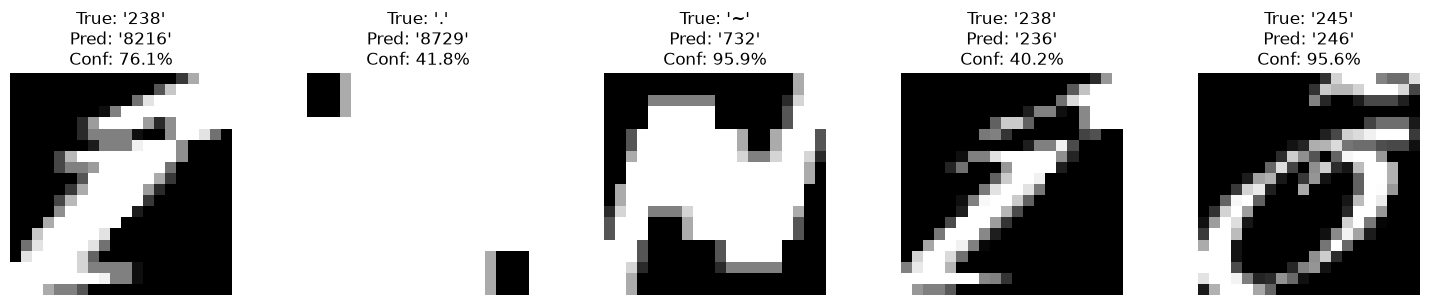

In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def analyze_misclassifications(model, test_loader, idx_to_char, device, num_images=5):
    model.eval()
    misclassified_samples = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Apply Softmax to get relative probabilities (0.0 to 1.0)
            probabilities = F.softmax(outputs, dim=1)
            
            # Get highest predicted class and its confidence score
            confidences, predictions = torch.max(probabilities, dim=1)
            
            # Find index positions where predictions do not match actual labels
            incorrect_mask = predictions != labels
            
            # Save misclassified data points
            for i in range(len(labels)):
                if incorrect_mask[i]:
                    misclassified_samples.append({
                        'image': inputs[i].cpu().squeeze().numpy(),
                        'true_label': idx_to_char[labels[i].item()],
                        'pred_label': idx_to_char[predictions[i].item()],
                        'confidence': confidences[i].item(),
                        'top3_probs': torch.topk(probabilities[i], 3)
                    })

    print(f"Total misclassifications found: {len(misclassified_samples)}")
    
    # Sort samples by confidence to find high-confidence errors or highly uncertain predictions
    # Plotting the first few misclassifications
    plt.figure(figsize=(15, 3))
    for i in range(min(num_images, len(misclassified_samples))):
        sample = misclassified_samples[i]
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(sample['image'], cmap='gray')
        
        # Display True vs Predicted character ascii values or symbols
        true_char = chr(sample['true_label']) if sample['true_label'] < 128 else sample['true_label']
        pred_char = chr(sample['pred_label']) if sample['pred_label'] < 128 else sample['pred_label']
        
        plt.title(f"True: '{true_char}'\nPred: '{pred_char}'\nConf: {sample['confidence']*100:.1f}%")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    return misclassified_samples

# Run the analysis on your best model
misclassified = analyze_misclassifications(improvedCnnModel, test_loader, idx_to_char, device)

In Vivaldi:
- '238' is i with a hat, while '305' is dotless i. Close.
- Something is not right our '.', which appears mostly solid. It was confused with '183', a "middle dot". 
- '732' is "small tilde". Understand to confuse this with normal tilde.
- '238', i with a hat again, in this case is being confused with i with an accent mark as the dot. Understandably close.
- '245' is o with a tilde over it, which is being confused with o with an umlaut over it. Understandably close.

### Step 4 - Denoising

Our first step for denoising data will be... to create noisy data from what we have!

In [24]:
noise_factor = 0.3
Xs_noisy = Xs_reshaped + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=Xs_reshaped.shape)
Xs_noisy = np.clip(Xs_noisy, 0., 1.)

# Split the same way, but keep clean/noisy pairs aligned
X_train_clean, X_test_clean, X_train_noisy, X_test_noisy = train_test_split(
    Xs_reshaped, Xs_noisy, test_size=0.2, random_state=42
)

train_ae_dataset = TensorDataset(
    torch.tensor(X_train_noisy, dtype=torch.float32),
    torch.tensor(X_train_clean, dtype=torch.float32)
)
train_ae_loader = DataLoader(train_ae_dataset, batch_size=64, shuffle=True)

We will define a new training function that uses MSError loss rather than our previous cross-entropy loss.

In [25]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encoder
        self.enc1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # 20->10->5

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')  # 5->10
        self.dec1 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.up2 = nn.Upsample(size=(20, 20), mode='nearest')   # 10->20 exactly
        self.dec2 = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.enc1(x)))
        x = self.pool(F.relu(self.enc2(x)))
        x = F.relu(self.dec1(self.up1(x)))
        x = torch.sigmoid(self.dec2(self.up2(x)))  # sigmoid: output pixels in [0,1]
        return x
    
def TrainAutoencoder(model, num_epochs, train_loader_local):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for noisy, clean in train_loader_local:
            noisy, clean = noisy.to(device), clean.to(device)
            optimizer.zero_grad()
            outputs = model(noisy)
            loss = criterion(outputs, clean)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * noisy.size(0)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {running_loss/len(train_loader_local.dataset):.4f}")

    return model

autoencoder = DenoisingAutoencoder()
TrainAutoencoder(autoencoder, 50, train_ae_loader)

Epoch [1/50] | Train Loss: 0.1789
Epoch [2/50] | Train Loss: 0.1250
Epoch [3/50] | Train Loss: 0.0885
Epoch [4/50] | Train Loss: 0.0776
Epoch [5/50] | Train Loss: 0.0691
Epoch [6/50] | Train Loss: 0.0640
Epoch [7/50] | Train Loss: 0.0603
Epoch [8/50] | Train Loss: 0.0571
Epoch [9/50] | Train Loss: 0.0540
Epoch [10/50] | Train Loss: 0.0513
Epoch [11/50] | Train Loss: 0.0489
Epoch [12/50] | Train Loss: 0.0472
Epoch [13/50] | Train Loss: 0.0459
Epoch [14/50] | Train Loss: 0.0445
Epoch [15/50] | Train Loss: 0.0437
Epoch [16/50] | Train Loss: 0.0426
Epoch [17/50] | Train Loss: 0.0418
Epoch [18/50] | Train Loss: 0.0411
Epoch [19/50] | Train Loss: 0.0404
Epoch [20/50] | Train Loss: 0.0399
Epoch [21/50] | Train Loss: 0.0392
Epoch [22/50] | Train Loss: 0.0389
Epoch [23/50] | Train Loss: 0.0383
Epoch [24/50] | Train Loss: 0.0377
Epoch [25/50] | Train Loss: 0.0375
Epoch [26/50] | Train Loss: 0.0373
Epoch [27/50] | Train Loss: 0.0368
Epoch [28/50] | Train Loss: 0.0361
Epoch [29/50] | Train Loss: 0

DenoisingAutoencoder(
  (enc1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (up1): Upsample(scale_factor=2.0, mode='nearest')
  (dec1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (up2): Upsample(size=(20, 20), mode='nearest')
  (dec2): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

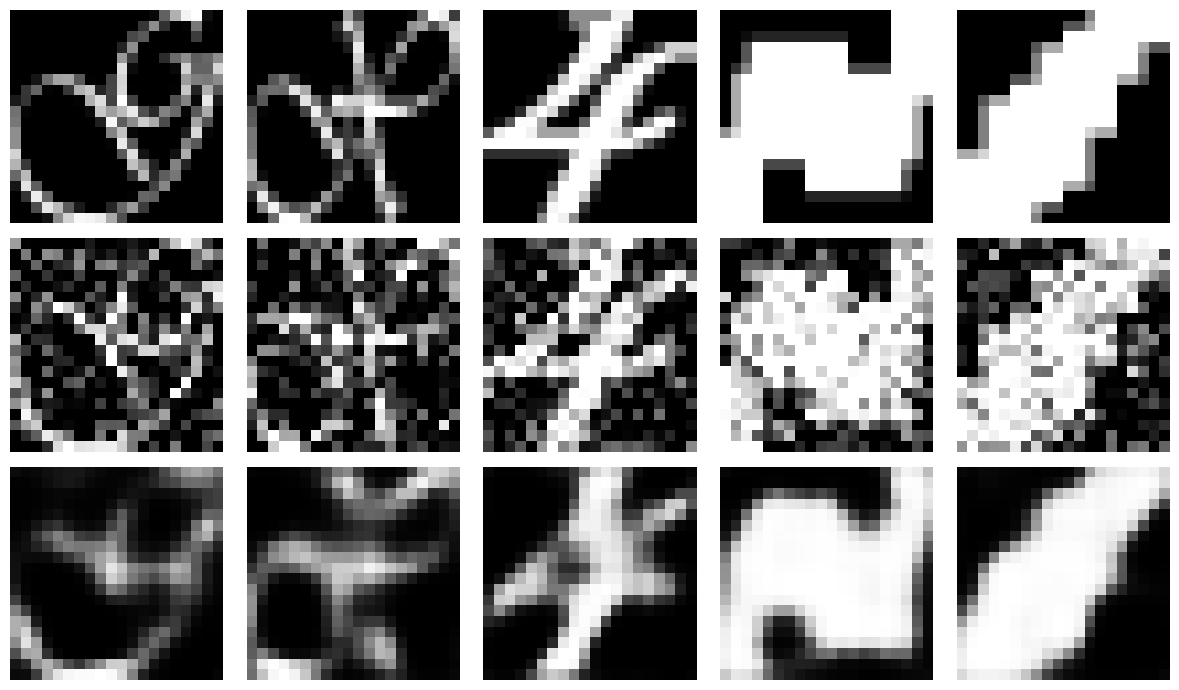

In [26]:
autoencoder.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_noisy = torch.tensor(X_test_noisy[:5], dtype=torch.float32).to(device)
sample_clean = X_test_clean[:5]

with torch.no_grad():
    denoised = autoencoder(sample_noisy).cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    axes[0, i].imshow(sample_clean[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(sample_noisy[i].cpu().squeeze(), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel("Clean"); axes[1, 0].set_ylabel("Noisy"); axes[2, 0].set_ylabel("Denoised")
plt.tight_layout()
plt.show()

We see mixed success from our denoiser model. It excelled at cleaning up the dark areas of the pictures, but the resulting characters are sometimes less interpretable than their noisy counter-parts, at least from my subjective experience. 